Upload kaggle.json file:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection
License(s): copyright-authors
  0% 0.00/15.1M [00:00<?, ?B/s]
100% 15.1M/15.1M [00:00<00:00, 1.94GB/s]
Found 406 images belonging to 3 classes.
Found 100 images belonging to 3 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


26/26 ━━━━━━━━━━━━━━━━━━━━ 16s 460ms/step - accuracy: 0.4852 - loss: 1.2537 - val_accuracy: 0.2900 - val_loss: 1.1557
Epoch 2/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 418ms/step - accuracy: 0.5468 - loss: 0.9053 - val_accuracy: 0.3000 - val_loss: 1.1719
Epoch 3/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 410ms/step - accuracy: 0.4930 - loss: 0.8883 - val_accuracy: 0.4800 - val_loss: 1.0570
Epoch 4/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 422ms/step - accuracy: 0.4847 - loss: 0.8653 - val_accuracy: 0.2400 - val_loss: 1.2678
Epoch 5/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 408ms/step - accuracy: 0.5170 - loss: 0.8367 - val_accuracy: 0.2300 - val_loss: 1.1885
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 392ms/step

Classification Report:
                     precision    recall  f1-score   support

brain_tumor_dataset       0.26      0.30      0.28        50
                 no       0.19      0.42      0.26        19
                yes       0.00      0.00      0.00        31

           accuracy                           0.23       100


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Saving brain.png to brain.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

Prediction: yes
Confidence: 59.43%


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


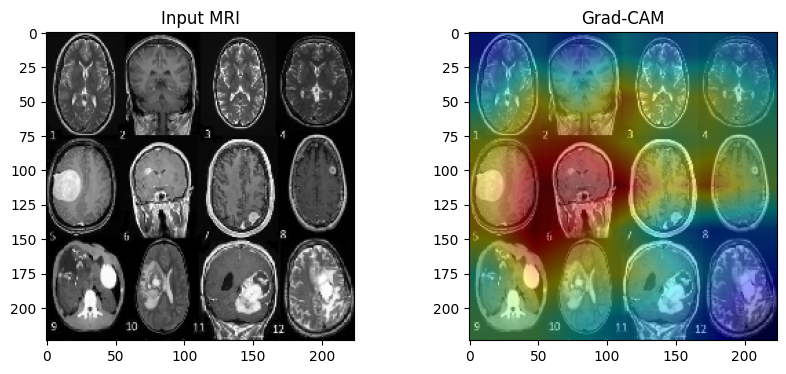


⚠️ Note: This model predicts tumor presence only.
⚠️ It is not clinically validated and should not be used for diagnosis.


In [1]:
# ==============================
# Brain Tumor Detection (Professional Version)
# MobileNetV2 + Grad-CAM + Evaluation
# ==============================

# -------- 1. Install Dependencies --------
!pip -q install tensorflow opencv-python kaggle scikit-learn

import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from google.colab import files

# -------- 2. Kaggle Setup --------
print("Upload kaggle.json file:")
files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# -------- 3. Download Dataset --------
!kaggle datasets download -d navoneel/brain-mri-images-for-brain-tumor-detection

with zipfile.ZipFile("brain-mri-images-for-brain-tumor-detection.zip", "r") as zip_ref:
    zip_ref.extractall("data")

data_dir = "data/"

# -------- 4. Data Preprocessing --------
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# -------- 5. Build Transfer Learning Model --------
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(train_gen.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# -------- 6. Train Model --------
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    verbose=1
)

# -------- 7. Evaluation --------
val_gen.reset()
predictions = model.predict(val_gen)
y_pred = np.argmax(predictions, axis=1)
y_true = val_gen.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=list(val_gen.class_indices.keys())))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

# -------- 8. Grad-CAM --------
def gradcam(model, img_array, layer_name):
    grad_model = Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_output, preds = grad_model(img_array)
        class_idx = tf.argmax(preds[0])
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_output = conv_output[0]

    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

# -------- 9. Upload Test MRI --------
print("\nUpload MRI image for testing:")
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

img = load_img(img_path, target_size=(224,224))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

prediction = model.predict(img_array)[0]
class_names = list(train_gen.class_indices.keys())
predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print(f"\nPrediction: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")

# -------- 10. Grad-CAM Visualization --------
heatmap = gradcam(model, img_array, layer_name='Conv_1')

img_cv = cv2.imread(img_path)
img_cv = cv2.resize(img_cv, (224,224))

heatmap_resized = cv2.resize(heatmap, (224,224))
heatmap_resized = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

superimposed = cv2.addWeighted(img_cv, 0.6, heatmap_color, 0.4, 0)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
plt.title("Input MRI")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM")
plt.show()

print("\n⚠️ Note: This model predicts tumor presence only.")
print("⚠️ It is not clinically validated and should not be used for diagnosis.")

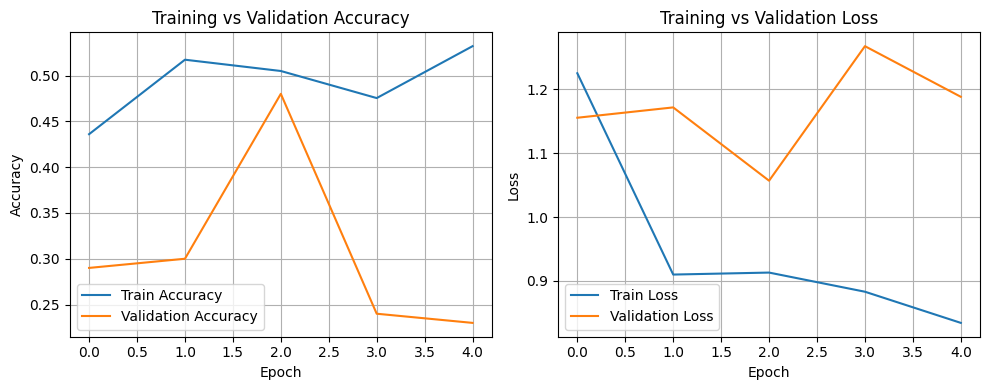

In [3]:
# -------- Save Training Accuracy & Loss Curves --------

plt.figure(figsize=(10,4))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("training_plot.png", dpi=300, bbox_inches='tight')
plt.show()